In [1]:
!pip install tensorflow tensorflow-hub tensorflow-datasets mlxtend scikit-learn numpy pandas matplotlib

You should consider upgrading via the 'C:\Users\adity\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_datasets as tfds

from sklearn import metrics
from mlxtend.plotting import plot_confusion_matrix

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [3]:
train_data, validation_data, test_data = tfds.load(
    name='imdb_reviews',
    split=('train[:60%]', 'train[60%:]', 'test'),
    as_supervised=True
)

In [4]:
train_examples_batch, train_labels_batch = next(iter(train_data.batch(10)))

train_labels_batch

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0])>

In [5]:
embedding = "https://tfhub.dev/google/nnlm-en-dim128-with-normalization/2"

In [6]:
# Create custom wrapper
class HubLayer(tf.keras.layers.Layer):

    def __init__(self, url):
        super().__init__()
        self.hub_layer = hub.KerasLayer(
            url,
            trainable=False,
            dtype=tf.string
        )

    def call(self, inputs):
        return self.hub_layer(inputs)

In [7]:
# Build model
inputs = tf.keras.Input(shape=(), dtype=tf.string)

x = HubLayer(embedding)(inputs)

x = tf.keras.layers.Dense(32, activation='relu')(x)

x = tf.keras.layers.Dense(16, activation='relu')(x)

outputs = tf.keras.layers.Dense(1)(x)

model = tf.keras.Model(inputs, outputs)

In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None)                      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hub_layer (HubLayer)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,673 (18.25 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_data.shuffle(10000).batch(256),
    epochs=5,
    validation_data=validation_data.batch(256),
    verbose=1
)

Epoch 1/5
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.5859 - loss: 0.6253 - val_accuracy: 0.7041 - val_loss: 0.5373
Epoch 2/5
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.7610 - loss: 0.4816 - val_accuracy: 0.7900 - val_loss: 0.4451
Epoch 3/5
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.7935 - loss: 0.4303 - val_accuracy: 0.8051 - val_loss: 0.4202
Epoch 4/5
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.8057 - loss: 0.4093 - val_accuracy: 0.8058 - val_loss: 0.4078
Epoch 5/5
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.8071 - loss: 0.4028 - val_accuracy: 0.8189 - val_loss: 0.4086


In [11]:
results = model.evaluate(test_data.batch(512), verbose=2)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.3f}")

49/49 - 3s - 68ms/step - accuracy: 0.8141 - loss: 0.4135
loss: 0.413
compile_metrics: 0.814


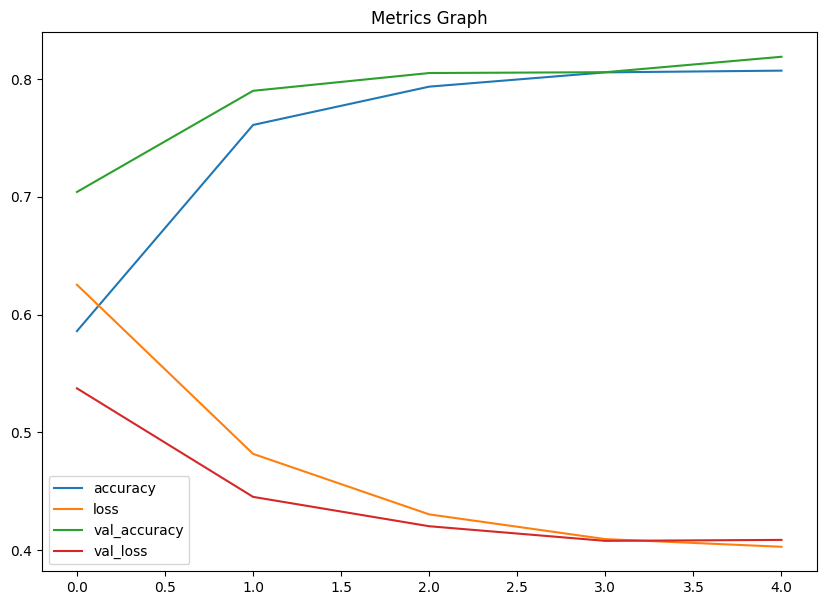

In [12]:
pd.DataFrame(history.history).plot(figsize=(10,7))

plt.title("Metrics Graph")

plt.show()

In [13]:
texts = []
true_labels = []

for text, label in test_data:
    texts.append(text.numpy().decode('utf-8'))
    true_labels.append(label.numpy())

true_labels = np.array(true_labels)

In [14]:
texts_tensor = tf.constant(texts)

predicted_probs = model.predict(texts_tensor)

predicted_labels = (predicted_probs > 0).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step


In [15]:
report = metrics.classification_report(
    true_labels,
    predicted_labels,
    target_names=['Negative', 'Positive']
)

print(report)

              precision    recall  f1-score   support

    Negative       0.84      0.78      0.81     12500
    Positive       0.79      0.85      0.82     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000



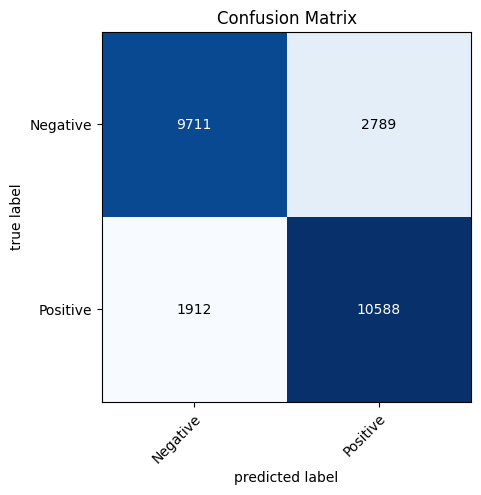

In [16]:
cm = metrics.confusion_matrix(true_labels, predicted_labels)

plot_confusion_matrix(cm, class_names=['Negative', 'Positive'])

plt.title("Confusion Matrix")

plt.show()